# Prac W3 - Unsupervised Learning

### Aims:

- To complement lecture material in understanding unsupervised learning
- To produce some assessable work for this subject

(**Q1**) Apply the $k$-means clustering algorithm (as implemented in Matlab or python scikit-learn)
to the heightweight dataset (second and third columns). Plot the resulting cluster centres
together with the data. Colour the data according to class label (first column)

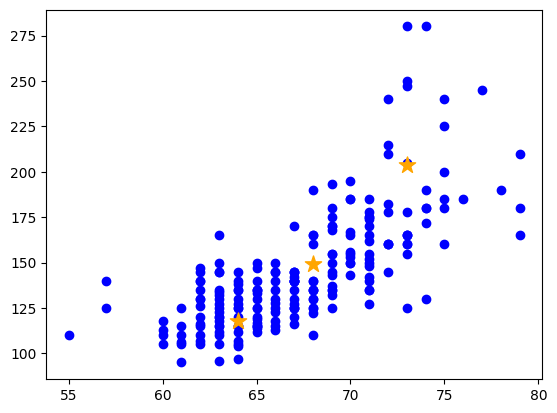

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from typing import List

DATA_FILEPATH: str = "./datasets/HeightWeightData.csv"

def load_data() -> pd.DataFrame:
    return pd.read_csv(DATA_FILEPATH, sep=",", header=None)

class KMeansClustering:
    # Member variables
    k: int
    max_iters: int
    tolerance: float
    centroids: np.ndarray

    # Private methods
    def _init_centroids(self, X: np.ndarray):
        indices: np.array = np.random.choice(X.shape[0], size=self.k, replace=False)
        self.centroids = X[indices]

    def _compute_distance(self, x_1: np.array, x_2: np.array) -> float:
        return np.sqrt(np.sum(np.square(x_1 - x_2)))

    # Public methods
    def __init__(self, k: int = 3, max_iters: int = 100, tolerance: float = 1e-4):
        self.k = k 
        self.max_iters = max_iters
        self.tolerance = tolerance

    def fit(self, X: np.ndarray) -> np.ndarray:
        # Randomly place centroids amongst space
        self._init_centroids(X)

        distance_moved: np.array = np.array(self.k * [sys.float_info.max])
        num_of_iters: int = 0
        while np.max(distance_moved) > self.tolerance and num_of_iters <= self.max_iters:
            # 1. Label data based on closest centroid
            labels_array: List[int] = []

            for x in X:
                distances: np.array = np.array([
                    self._compute_distance(x, centroid) for centroid in self.centroids
                ])

                labels_array.append(np.argmin(distances))

            labels: np.array = np.array(labels_array)

            # 2. Move centroid by taking the mean of the corresponding label data
            for centroid_idx in range(0, self.k):
                indices: np.array = np.where(labels == centroid_idx)
                new_centroid: np.array = np.mean(X[indices], axis=0)
                distance_moved[centroid_idx] = self._compute_distance(
                    self.centroids[centroid_idx], new_centroid
                )
                self.centroids[centroid_idx] = new_centroid

            num_of_iters += 1

        return self.centroids

def plot_kmc(model: KMeansClustering, X: np.ndarray) -> None:
    plt.scatter(X[:, 0], X[:, 1], color="blue")
    plt.scatter(model.centroids[:, 0], model.centroids[:, 1], color="orange", marker="*", s=150)
    plt.show()

df: pd.DataFrame = load_data()
model: KMeansClustering = KMeansClustering(3)
X: np.ndarray = df.iloc[:, 1:].to_numpy()
model.fit(X)
plot_kmc(model, X)

(**Q2**) Write a python function implementing PCA

In [34]:
class PCA:
    # Member Variables
    n_components: int 
    components: np.ndarray
    mean: np.array
    eigenvalues: np.array
    total_variance: int = 0

    # Private Methods
    def _fit(self, X: np.ndarray) -> None:
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centred: np.ndarray = X - self.mean 

        # Get covariance matrix
        cov_matrix: np.ndarray = np.cov(X_centred, rowvar=False)

        # Get eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        self.total_variance = np.sum(eigenvalues)

        # Sort in descending order
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.components = eigenvectors[:, idx]

        # Store only the top n_components
        self.components = self.components[:, :self.n_components]
        self.eigenvalues = self.eigenvalues[:self.n_components]
    
    def _get_explained_variance_ratio(self) -> np.ndarray:
        return self.eigenvalues / self.total_variance

    # Public Methods
    def __init__(self, n_components: int = 2):
        self.n_components = n_components

    def transform(self, X: np.ndarray) -> np.ndarray:
        X_centered = X - self.mean 
        return np.dot(X_centered, self.components)
    
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        self._fit(X)
        return self.transform(X)
    
    def get_total_explained_variance(self) -> float:
        return np.sum(self._get_explained_variance_ratio()) * 100

(**Q3**) Run your PCA function on the MNIST data

In [35]:
from sklearn.datasets import fetch_openml
from typing import Tuple 

def get_mnist_data() -> Tuple[np.ndarray, np.array]:
    mnist = fetch_openml('mnist_784', version=1, parser='auto')
    return mnist.data, mnist.target.astype(int)

mnist_x, mnist_y = get_mnist_data()
pca: PCA = PCA(2)
mnist_x_transformed: np.ndarray = pca.fit_transform(mnist_x)
print(f"Original Shape: {mnist_x.shape}")
print(f"Transformed Shape: {mnist_x_transformed.shape}")

Original Shape: (70000, 784)
Transformed Shape: (70000, 2)


(**Q4**) Produce a plot of the data in the space spanned by the first two principal components. 
Colour each point by its class

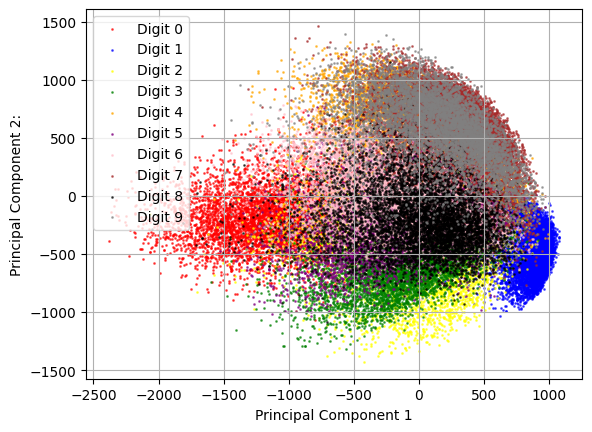

In [36]:
from typing import List

colors: List[str] = ["red", "blue", "yellow", "green", "orange", "purple", "pink", "brown", 
    "black", "gray"]

def plot_mnist_transformed(x_transformed: np.ndarray, y: np.array) -> None:
    for digit in range(10):
        mask = (y == digit)

        plt.scatter(
            x_transformed[mask, 0],
            x_transformed[mask, 1],
            s=1,
            alpha=0.6,
            label=f"Digit {digit}",
            color=colors[digit]
        )

    plt.grid()
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2:")
    plt.legend()
    plt.show()

plot_mnist_transformed(mnist_x_transformed, mnist_y)

(**Q5**) What percentage of the data variance is accounted for by the first two principal components?

In [41]:
print(f"Explained Variance: {pca.get_total_explained_variance():.2f} %")

Explained Variance: 16.90 %


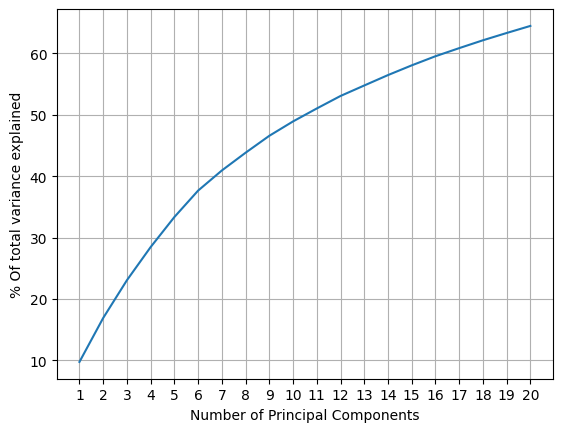

In [50]:
def plot_pca_scree_graph(x: np.ndarray, max_k: int) -> None:
    pca = PCA(max_k)
    pca._fit(x)

    ratios = pca._get_explained_variance_ratio()
    cumulative_variance = np.cumsum(ratios) * 100

    n_components_grid = np.arange(1, max_k + 1)

    plt.plot(n_components_grid, cumulative_variance)
    plt.xlabel("Number of Principal Components")
    plt.ylabel("% Of total variance explained")
    plt.xticks(n_components_grid)
    plt.grid()
    plt.show()

plot_pca_scree_graph(mnist_x, 20)

(**Q6**) Repeat the procdeure in (Q3-6) using the Swiss Roll dataset. Comment briefly on the results

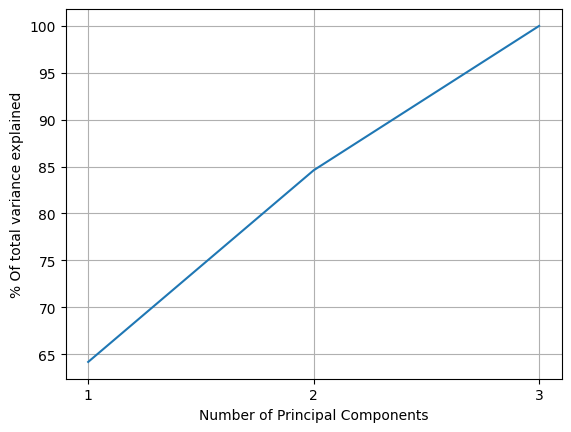

In [54]:
def get_swiss_roll_data() -> np.ndarray:
    return np.loadtxt("./datasets/swissroll.txt")

swissroll_x: np.ndarray = get_swiss_roll_data()
plot_pca_scree_graph(swissroll_x, 3)

By plotting a scree graph of the swiss roll data, it can be seen that even just one principal component can capture a majority of the variance in the data. It also makes sense that having 3 principal components captures 100% of the variance, as the dataset has 3 total features